In [1]:
!pip install qwen-vl-utils
!git clone https://github.com/hcompai/hai-cookbook/

%cd hai-cookbook
!hf download Hcompany/Holo2-4B --local-dir ./models/halo2-4b

!curl -L -o onenote.png "https://raw.githubusercontent.com/YaraHisham61/Click2Act/exp-models-benchmarks/imgs/onenote.png"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 46.6 MB/s eta 0:00:00:00:0100:01
Cloning into 'hai-cookbook'...
remote: Enumerating objects: 204, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 204 (delta 70), reused 59 (delta 52), pack-reused 105 (from 1)
Receiving objects: 100% (204/204), 8.45 MiB | 22.96 MiB/s, done.
Resolving deltas: 100% (96/96), done.
/kaggle/working/hai-cookbook
A new version of huggingface_hub (1.11.0) is available! You are using version 1.4.1.
To update, run: pip install -U huggingface_hub

Fetching 18 files:   0%|                                 | 0/18 [00:00<?, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Still waiting to acquire lock on models/halo2-4b/.cache/huggingface/.gitignore.lock (elapsed: 0.1 seconds)
Fetching 18 files: 100%|████████████████████████| 18/18 [00:36<00:00,  2.05s/

In [2]:
from typing import Any, Literal, TypeAlias

import requests
import torch
from PIL import Image
from pydantic import BaseModel, Field
from transformers import AutoModelForImageTextToText, AutoProcessor
from transformers.models.qwen2_vl.image_processing_qwen2_vl import smart_resize

In [3]:
model_path = './models/halo2-4b'
device = 'cuda'
C2A_PALETTE = {
    "primary"   : "#2E86AB",
    "secondary" : "#A23B72",
    "tertiary"  : "#F18F01",
    "neutral"   : "#6C757D",
    "success"   : "#3BB273",
    "warning"   : "#E84855",
    "bg"        : "#F8F9FA",
    "text"      : "#212529",
}

temperature: float = 0
max_new_tokens: int = 1024


In [4]:
import torch
import numpy as np
from PIL import Image, ImageDraw
import numpy as np

def draw_click(image, x: int, y: int, radius: int = 20, opacity: float = 0.6,
               color: str = None):
    """Overlay a semi-transparent circle on an image to mark a click point.

    Args:
        image   : PIL.Image or numpy array (H, W, 3).
        x, y    : pixel coordinates of the circle centre.
        radius  : circle radius in pixels.
        opacity : alpha in [0, 1] — 0 = invisible, 1 = fully opaque.
        color   : hex colour string (default: C2A_PALETTE["warning"]).
        figsize : matplotlib figure size (used only when ax is None).
        ax      : existing Axes to draw on, or None for a standalone figure.
    """
    if color is None:
        color = C2A_PALETTE["warning"]

    # --- normalise to PIL RGB ---
    if isinstance(image, np.ndarray):
        pil_img = Image.fromarray(image.astype(np.uint8)).convert("RGB")
    else:
        pil_img = image.convert("RGB")

    # --- parse hex colour to RGB tuple ---
    hex_color = color.lstrip("#")
    rgb = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

    # --- draw circle on a transparent overlay ---
    overlay = Image.new("RGBA", pil_img.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    alpha = int(opacity * 255)
    bbox = [x - radius, y - radius, x + radius, y + radius]
    draw.ellipse(bbox, fill=(*rgb, alpha), outline=(*rgb, 255), width=2)

    # --- composite onto the original ---
    result = Image.alpha_composite(pil_img.convert("RGBA"), overlay).convert("RGB")
    

    return result


In [5]:
image_path = 'onenote.png'
image = Image.open(image_path)
image_rgb = image.convert('RGB')
image_np = np.array(image_rgb)
w, h = image_rgb.size
print('image size:', w, h)

image size: 1919 1079


In [6]:
model = AutoModelForImageTextToText.from_pretrained(
    model_path,
    dtype=torch.float16,
    device_map="auto",
)
processor = AutoProcessor.from_pretrained(model_path)

Loading weights:   0%|          | 0/714 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [7]:
image_processor_config = processor.image_processor
resized_height, resized_width = smart_resize(
    image_rgb.height,
    image_rgb.width,
    factor=image_processor_config.patch_size * image_processor_config.merge_size,
    min_pixels=image_processor_config.size.get("shortest_edge", None),
    max_pixels=image_processor_config.size.get("longest_edge", None),
)

processed_image = image_rgb.resize(size=(resized_width, resized_height), resample=Image.Resampling.LANCZOS)


In [8]:
class ClickCoordinates(BaseModel):
    x: int = Field(ge=0, le=1000, description="The x coordinate, normalized between 0 and 1000.")
    y: int = Field(ge=0, le=1000, description="The y coordinate, normalized between 0 and 1000.")

ChatMessage: TypeAlias = dict[str, Any]


def get_chat_messages(task: str, image: Image.Image) -> list[ChatMessage]:
    """Create the prompt structure for navigation task"""
    prompt = f"""Localize an element on the GUI image according to the provided target and output a click position.
     * You must output a valid JSON following the format: {ClickCoordinates.model_json_schema()}
     Your target is:"""

    return [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": f"{prompt}\n{task}"},
            ],
        },
    ]


# Example 1

In [9]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [10]:
task = "add new page"
# Create the prompt
messages: list[dict[str, Any]] = get_chat_messages(task, processed_image)

# Apply chat template
# Note - For localization we set thinking to False
text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, thinking=False)

# Process inputs
inputs = processor(
    text=[text_prompt],
    images=[processed_image],
    padding=True,
    return_tensors="pt",
).to(model.device)



In [11]:
model.eval()
with torch.no_grad():
    generated_ids = model.generate(**inputs, max_new_tokens=32)

In [12]:
output_text = processor.batch_decode(generated_ids, skip_special_tokens=True)

In [13]:
print(output_text[0])

user
Localize an element on the GUI image according to the provided target and output a click position.
     * You must output a valid JSON following the format: {'properties': {'x': {'description': 'The x coordinate, normalized between 0 and 1000.', 'maximum': 1000, 'minimum': 0, 'title': 'X', 'type': 'integer'}, 'y': {'description': 'The y coordinate, normalized between 0 and 1000.', 'maximum': 1000, 'minimum': 0, 'title': 'Y', 'type': 'integer'}}, 'required': ['x', 'y'], 'title': 'ClickCoordinates', 'type': 'object'}
     Your target is:
add new page
assistant
<think>

</think>

{"x":125,"y":932}


In [14]:
x_model, y_model = 112, 930
w, h = processed_image.size
new_coordinate = (int(x_model/1000 * w), int(y_model/1000 * h))
print(new_coordinate)

(215, 1011)


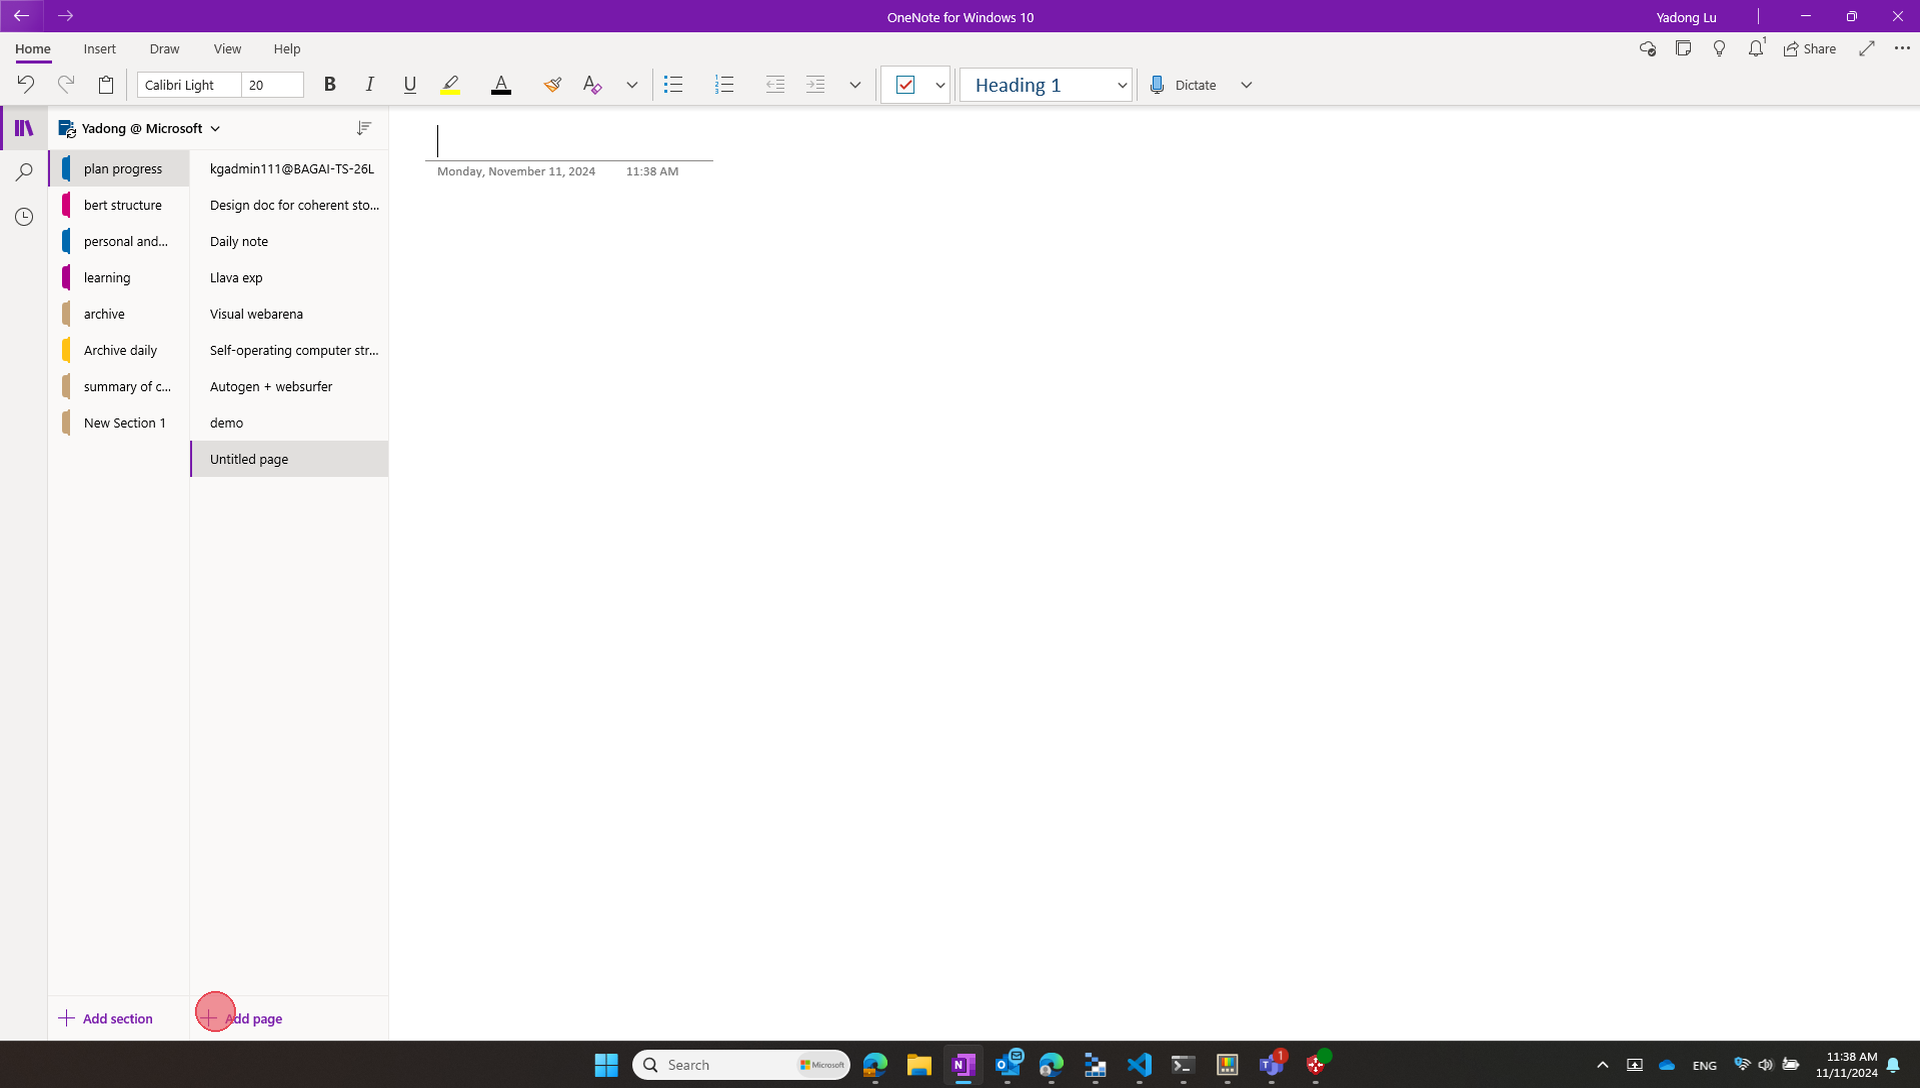

In [15]:
draw_click(processed_image, new_coordinate[0], new_coordinate[1])

# Example 1 (Clean)

In [18]:
task = "add new page"
# Create the prompt
messages: list[dict[str, Any]] = get_chat_messages(task, image_rgb)
# Apply chat template
# Note - For localization we set thinking to False
text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, thinking=False)
# Process inputs
inputs = processor(text=[text_prompt], images=[processed_image], padding=True, return_tensors="pt",).to(model.device)
# generate tokens
generated_ids = model.generate(**inputs, max_new_tokens=32)
generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
# decode tokens
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)
output_text[0]

'{"x":133,"y":931}'

(255, 1004)


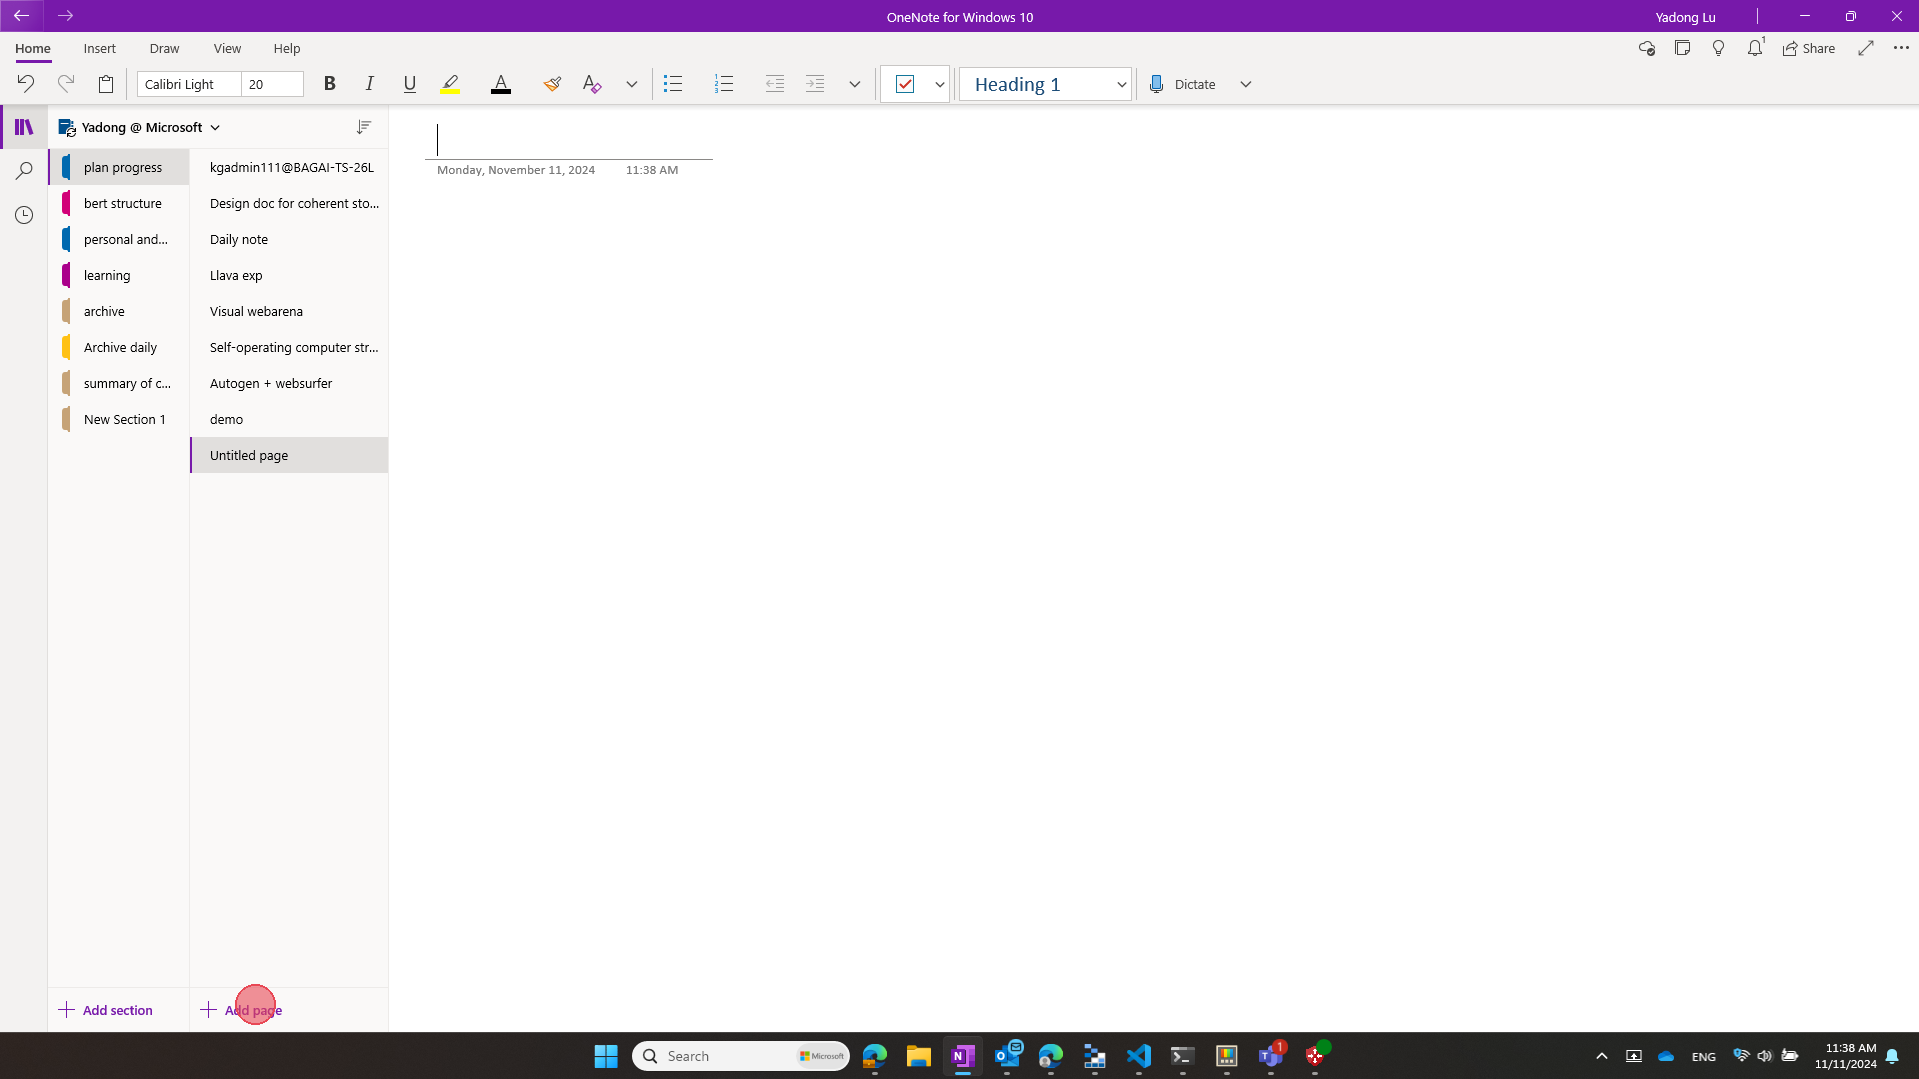

In [20]:
import json
res = json.loads(output_text[0])
x_model, y_model = res['x'], res['y']
w, h = image_rgb.size
new_coordinate = (int(x_model/1000 * w), int(y_model/1000 * h))
print(new_coordinate)

draw_click(image_rgb, new_coordinate[0], new_coordinate[1])

# Example 2

(264, 91)


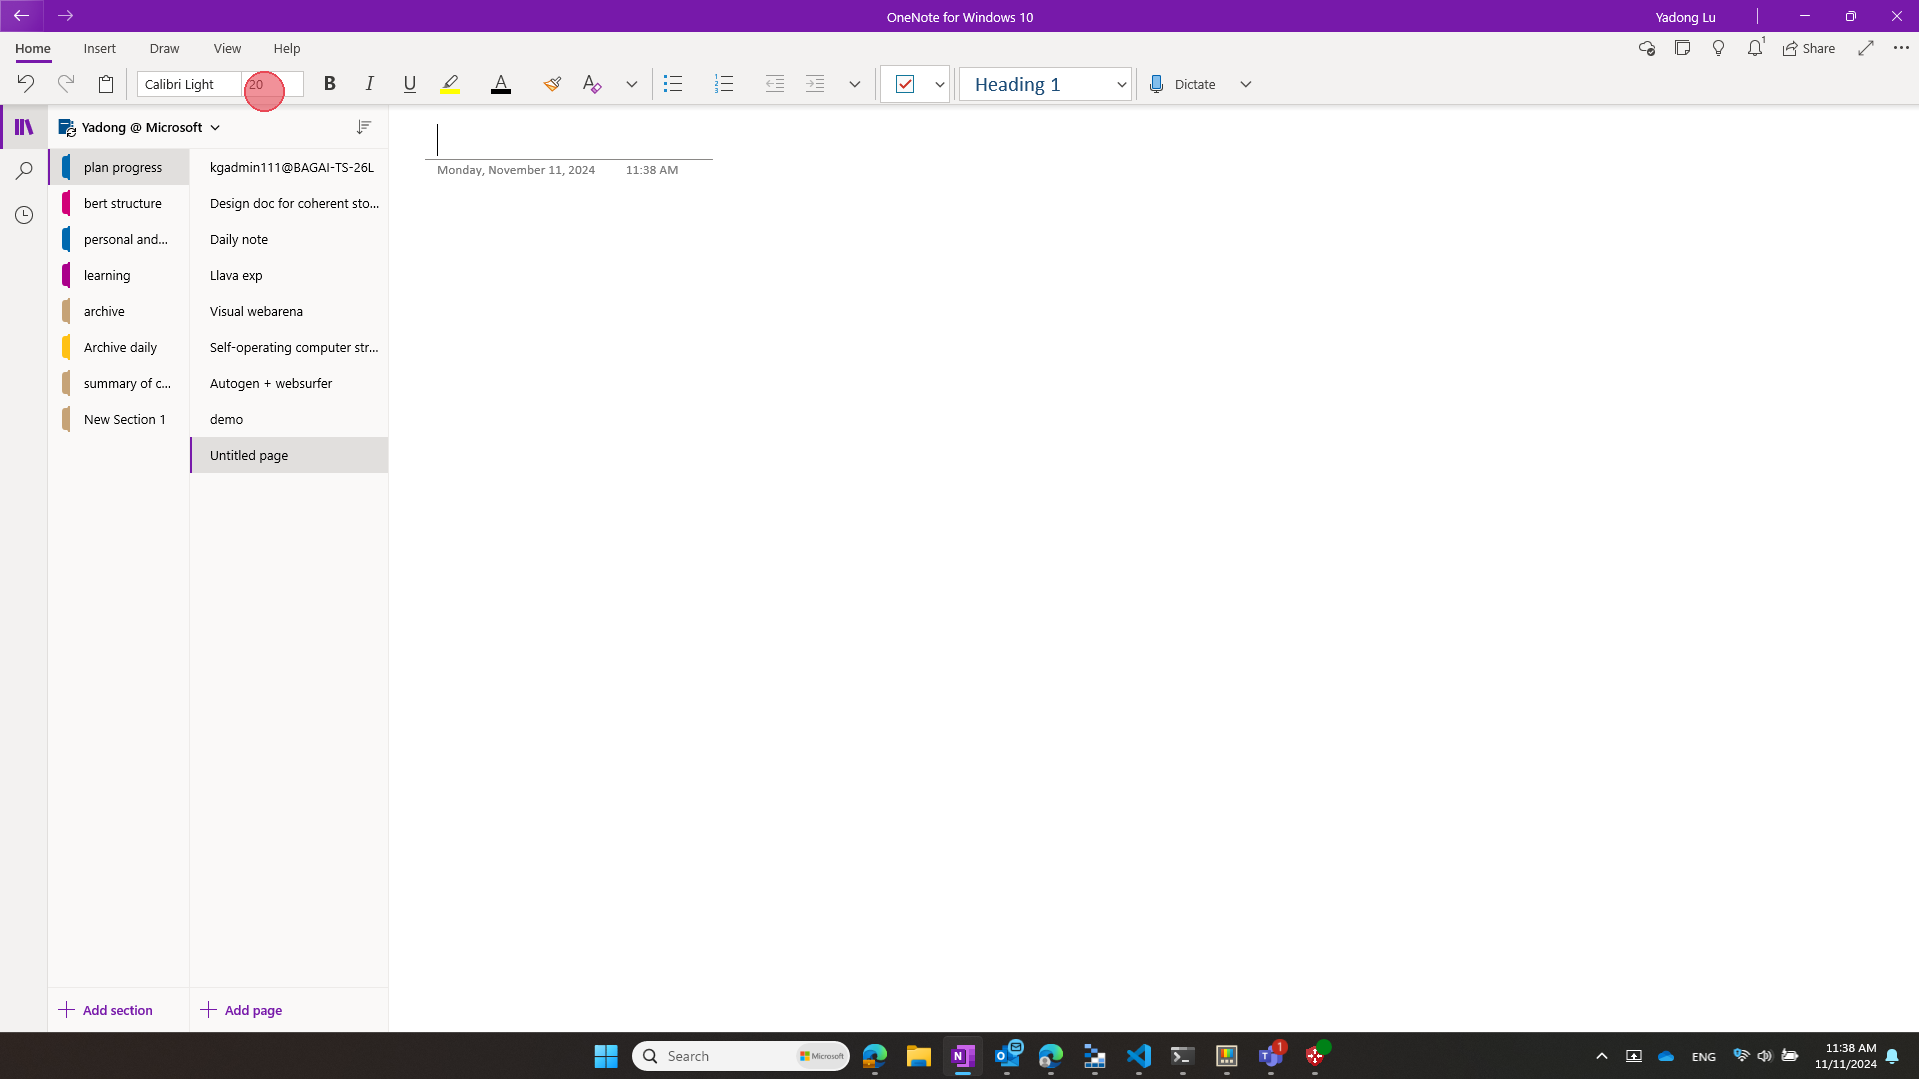

In [21]:
task = "change font size to 32"
# Create the prompt
messages: list[dict[str, Any]] = get_chat_messages(task, image_rgb)
# Apply chat template
# Note - For localization we set thinking to False
text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, thinking=False)
# Process inputs
inputs = processor(text=[text_prompt], images=[processed_image], padding=True, return_tensors="pt",).to(model.device)
# generate tokens
generated_ids = model.generate(**inputs, max_new_tokens=32)
generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
# decode tokens
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)
output_text[0]
# ======================================
res = json.loads(output_text[0])
x_model, y_model = res['x'], res['y']
w, h = image_rgb.size
new_coordinate = (int(x_model/1000 * w), int(y_model/1000 * h))
print(new_coordinate)

draw_click(image_rgb, new_coordinate[0], new_coordinate[1])

# Example 3

(1644, 59)


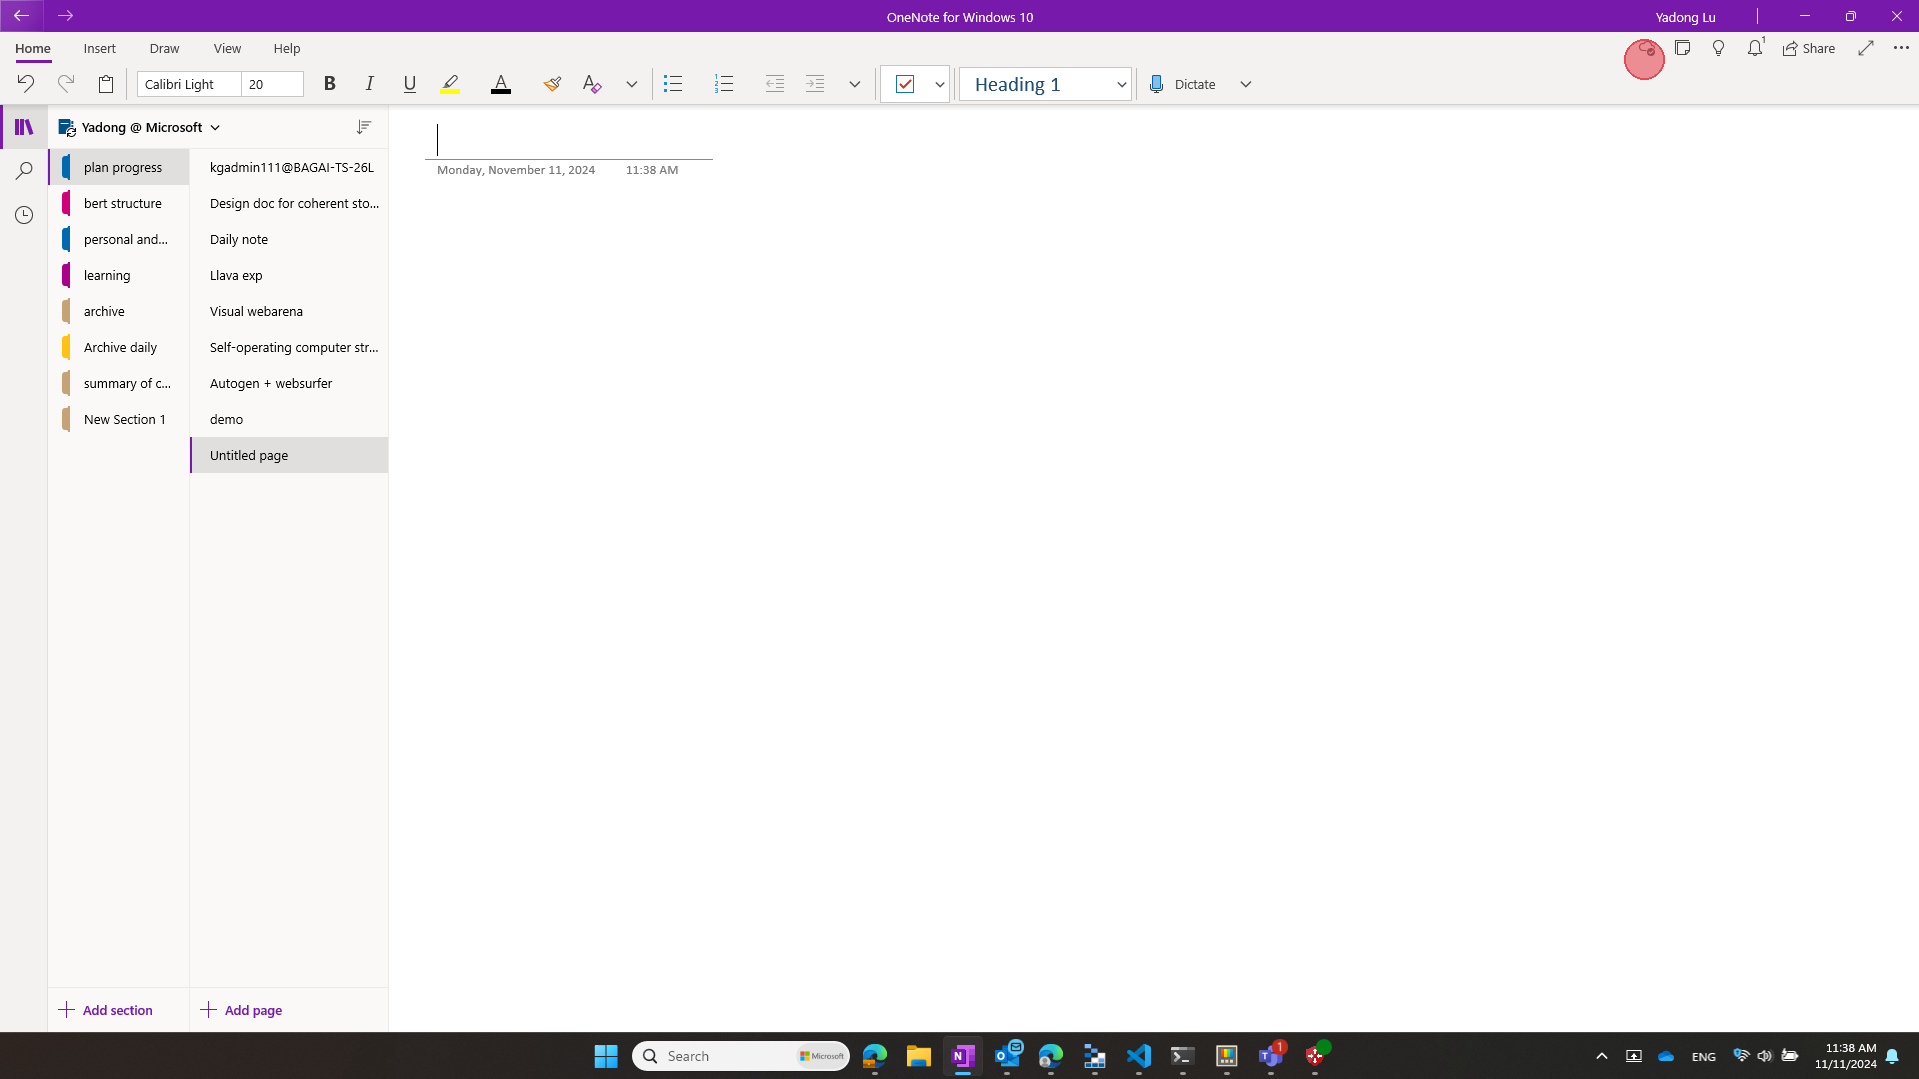

In [22]:
task = "save notebook to the cloud"
# Create the prompt
messages: list[dict[str, Any]] = get_chat_messages(task, image_rgb)
# Apply chat template
# Note - For localization we set thinking to False
text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, thinking=False)
# Process inputs
inputs = processor(text=[text_prompt], images=[processed_image], padding=True, return_tensors="pt",).to(model.device)
# generate tokens
generated_ids = model.generate(**inputs, max_new_tokens=32)
generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
# decode tokens
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)
output_text[0]
# ======================================
res = json.loads(output_text[0])
x_model, y_model = res['x'], res['y']
w, h = image_rgb.size
new_coordinate = (int(x_model/1000 * w), int(y_model/1000 * h))
print(new_coordinate)

draw_click(image_rgb, new_coordinate[0], new_coordinate[1])

# Example 4

(452, 75)


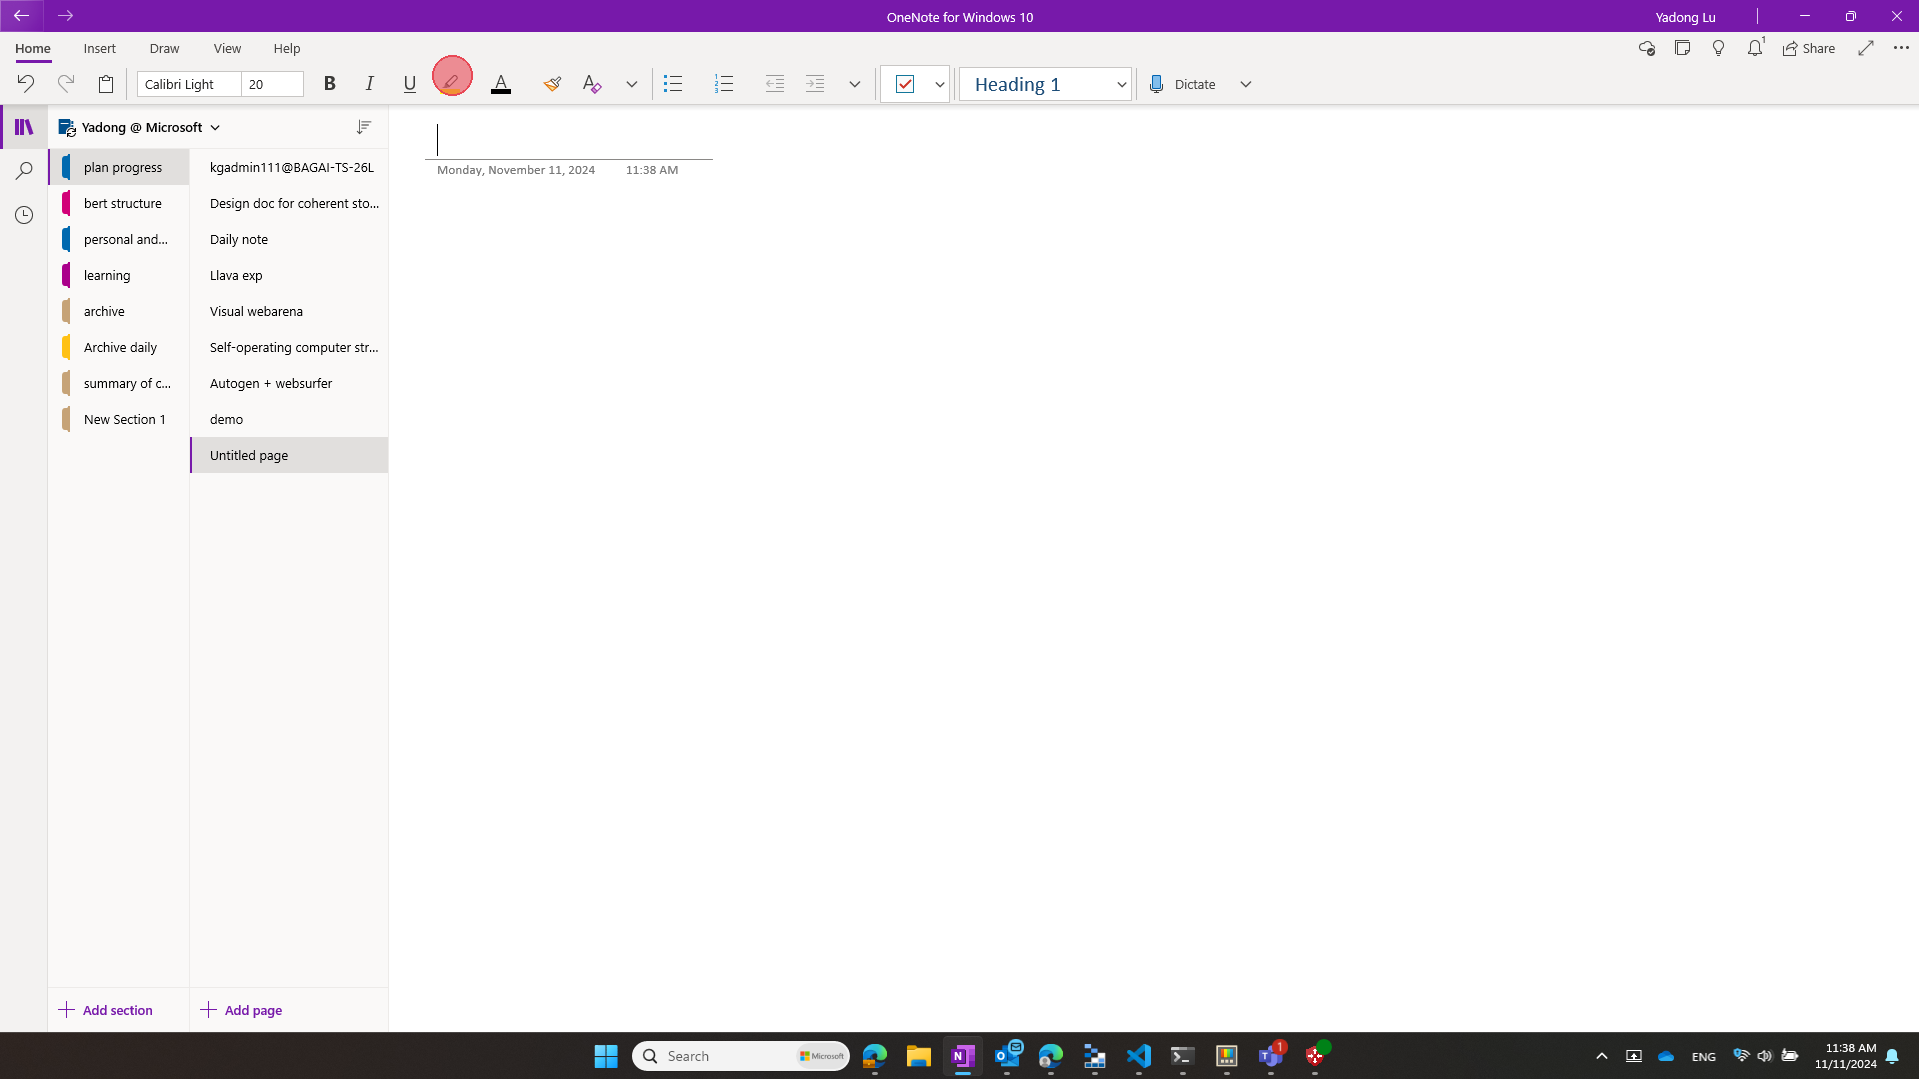

In [23]:
task = "select text highlighter"
# Create the prompt
messages: list[dict[str, Any]] = get_chat_messages(task, image_rgb)
# Apply chat template
# Note - For localization we set thinking to False
text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, thinking=False)
# Process inputs
inputs = processor(text=[text_prompt], images=[processed_image], padding=True, return_tensors="pt",).to(model.device)
# generate tokens
generated_ids = model.generate(**inputs, max_new_tokens=32)
generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
# decode tokens
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)
output_text[0]
# ======================================
res = json.loads(output_text[0])
x_model, y_model = res['x'], res['y']
w, h = image_rgb.size
new_coordinate = (int(x_model/1000 * w), int(y_model/1000 * h))
print(new_coordinate)

draw_click(image_rgb, new_coordinate[0], new_coordinate[1])

# Example 5

(316, 234)


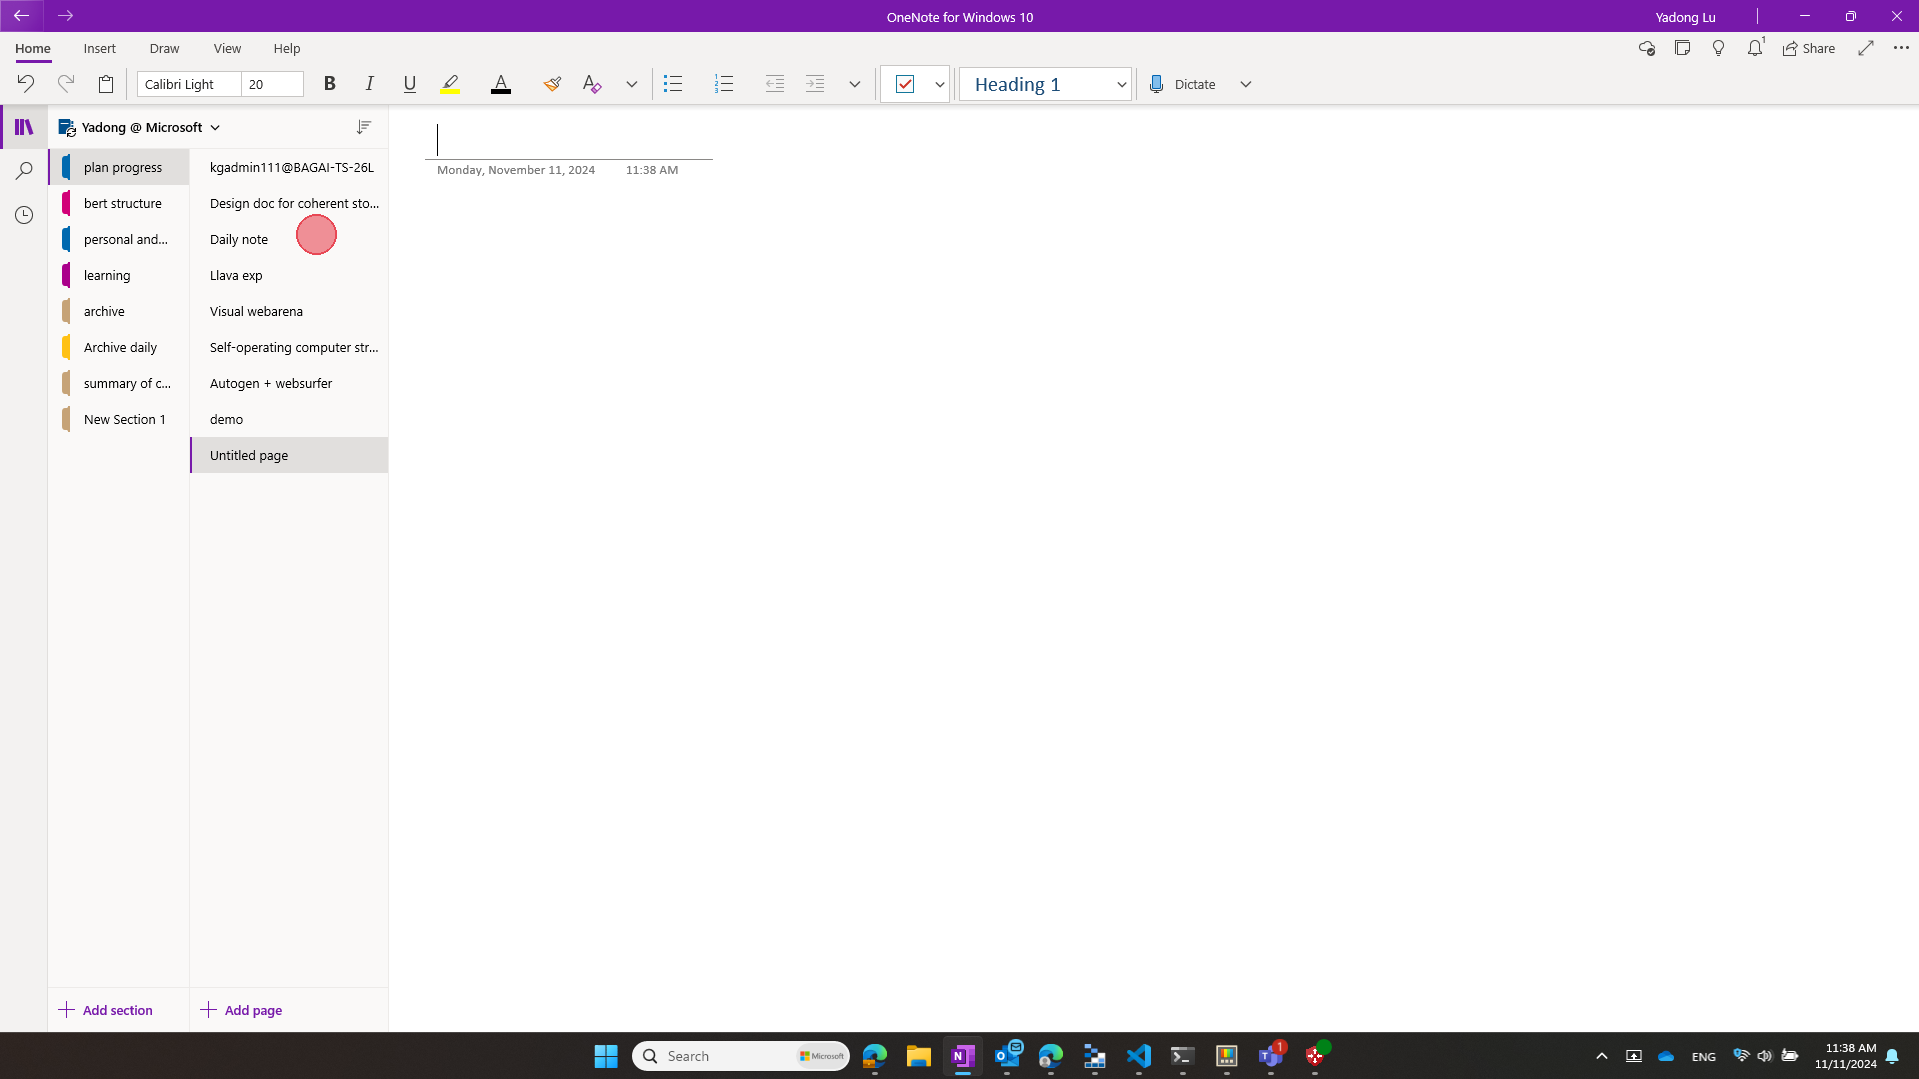

In [24]:
task = "select 'Daily Notes'"
# Create the prompt
messages: list[dict[str, Any]] = get_chat_messages(task, image_rgb)
# Apply chat template
# Note - For localization we set thinking to False
text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, thinking=False)
# Process inputs
inputs = processor(text=[text_prompt], images=[processed_image], padding=True, return_tensors="pt",).to(model.device)
# generate tokens
generated_ids = model.generate(**inputs, max_new_tokens=32)
generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
# decode tokens
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)
output_text[0]
# ======================================
res = json.loads(output_text[0])
x_model, y_model = res['x'], res['y']
w, h = image_rgb.size
new_coordinate = (int(x_model/1000 * w), int(y_model/1000 * h))
print(new_coordinate)

draw_click(image_rgb, new_coordinate[0], new_coordinate[1])

# Example 6

(1256, 1056)


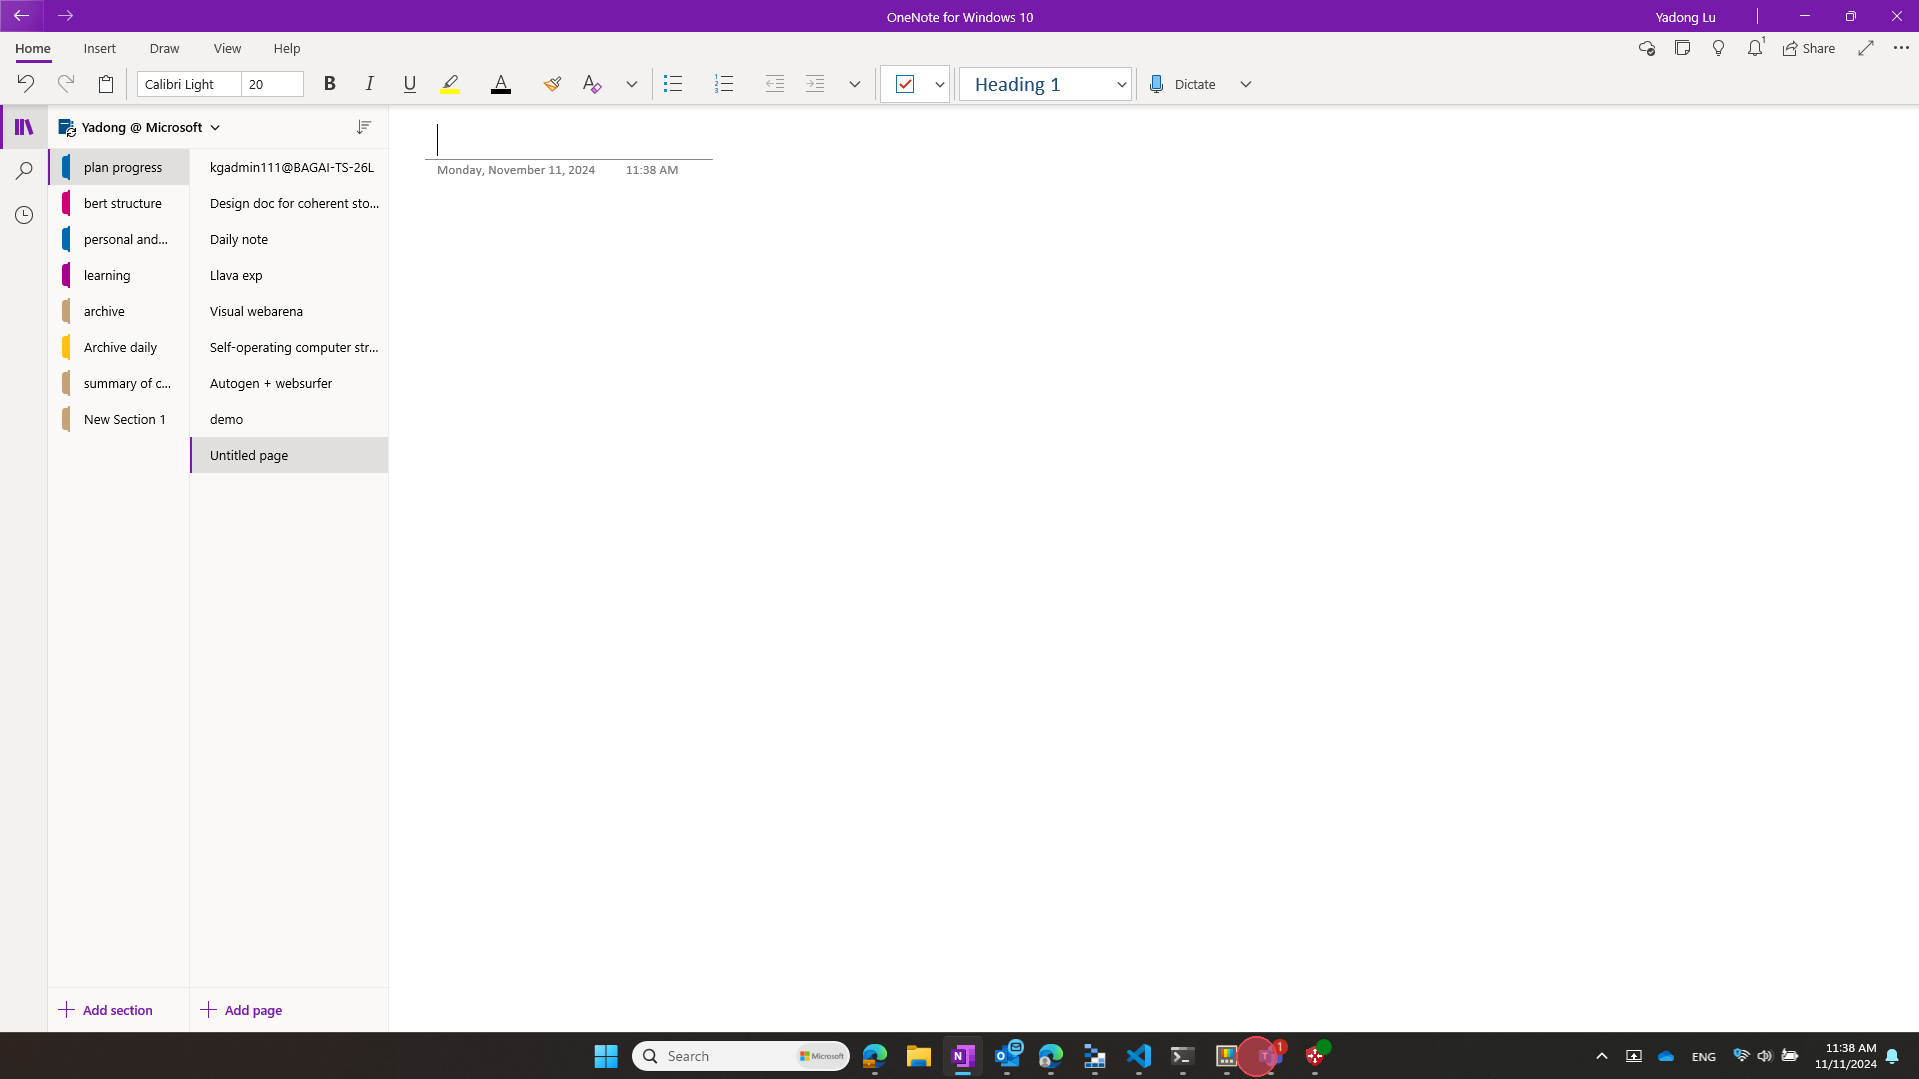

In [25]:
task = "Open Teams app"
# Create the prompt
messages: list[dict[str, Any]] = get_chat_messages(task, image_rgb)
# Apply chat template
# Note - For localization we set thinking to False
text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, thinking=False)
# Process inputs
inputs = processor(text=[text_prompt], images=[processed_image], padding=True, return_tensors="pt",).to(model.device)
# generate tokens
generated_ids = model.generate(**inputs, max_new_tokens=32)
generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
# decode tokens
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)
output_text[0]
# ======================================
res = json.loads(output_text[0])
x_model, y_model = res['x'], res['y']
w, h = image_rgb.size
new_coordinate = (int(x_model/1000 * w), int(y_model/1000 * h))
print(new_coordinate)

draw_click(image_rgb, new_coordinate[0], new_coordinate[1])

# Example 7

(1656, 1039)


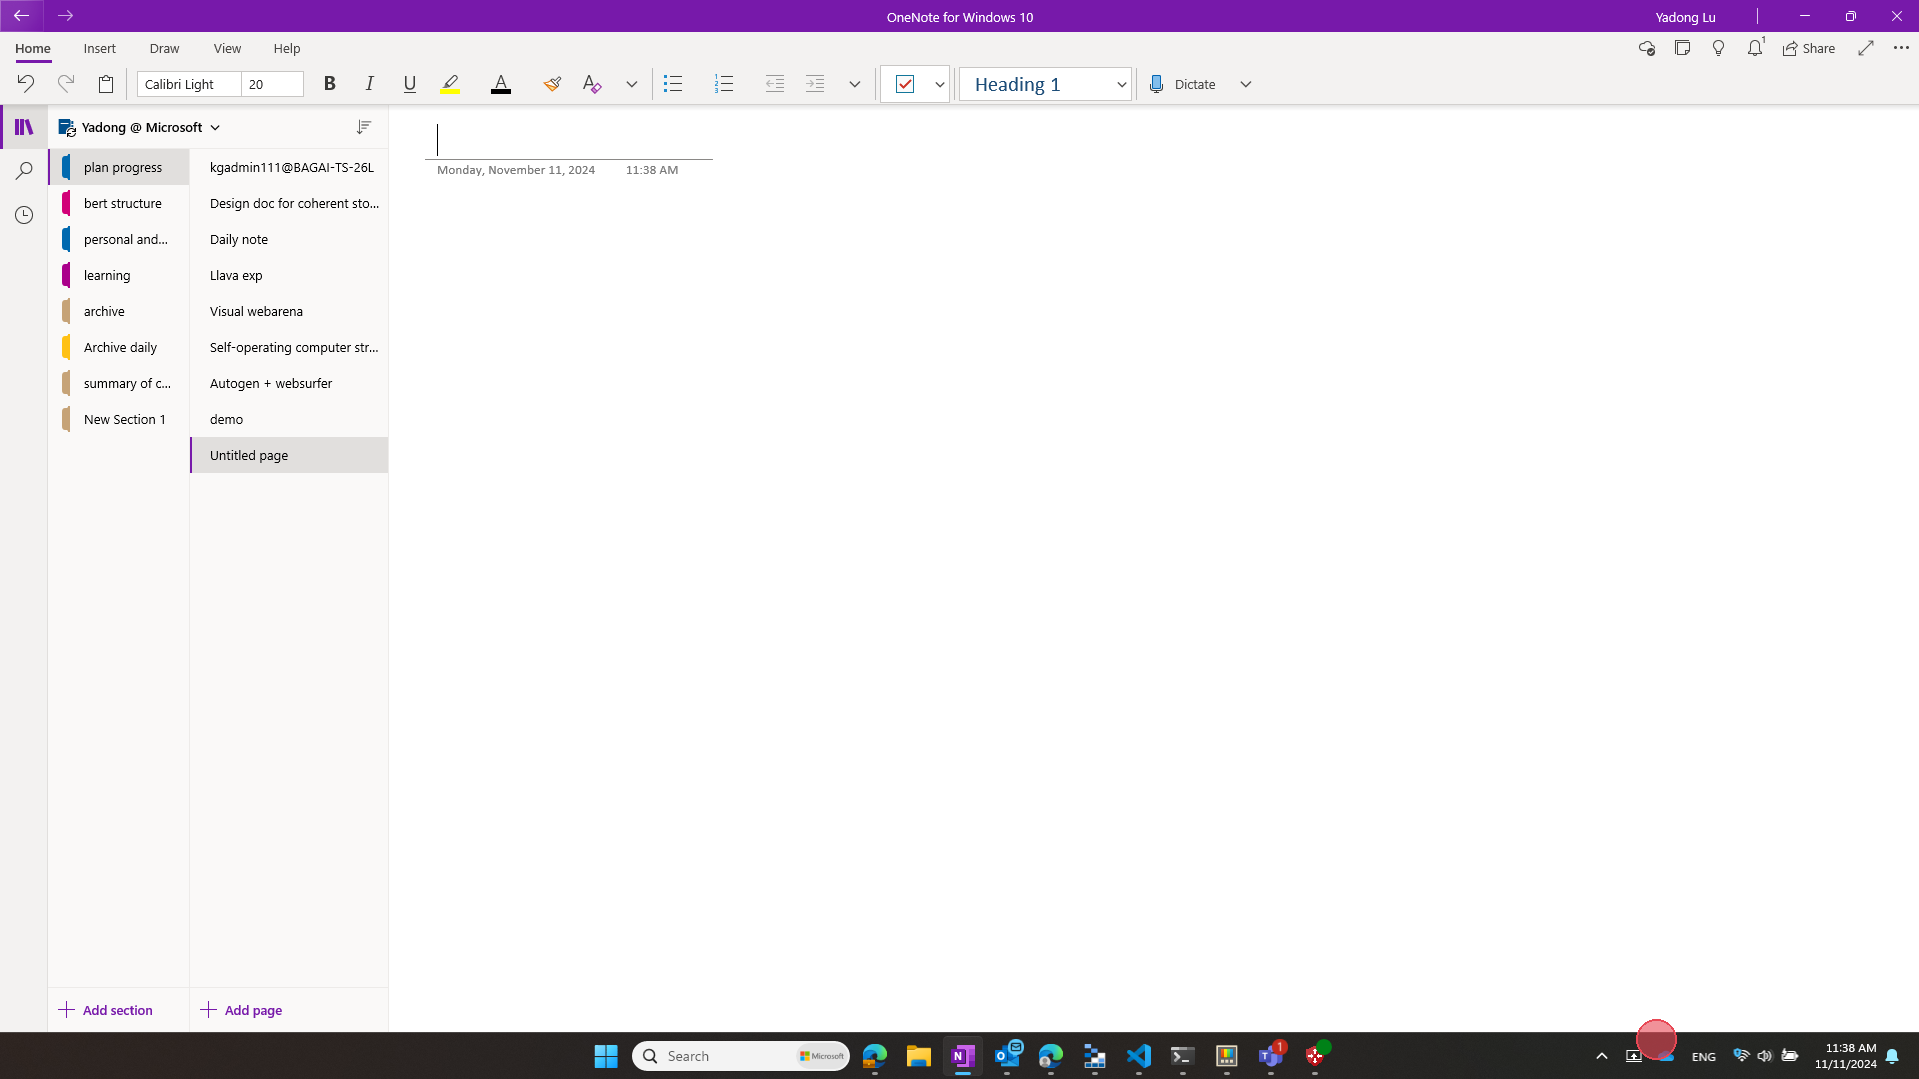

In [26]:
task = "change WIFI network"
# Create the prompt
messages: list[dict[str, Any]] = get_chat_messages(task, image_rgb)
# Apply chat template
# Note - For localization we set thinking to False
text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, thinking=False)
# Process inputs
inputs = processor(text=[text_prompt], images=[processed_image], padding=True, return_tensors="pt",).to(model.device)
# generate tokens
generated_ids = model.generate(**inputs, max_new_tokens=32)
generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
# decode tokens
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)
output_text[0]
# ======================================
res = json.loads(output_text[0])
x_model, y_model = res['x'], res['y']
w, h = image_rgb.size
new_coordinate = (int(x_model/1000 * w), int(y_model/1000 * h))
print(new_coordinate)

draw_click(image_rgb, new_coordinate[0], new_coordinate[1])